In [13]:
# Importando os pacotes das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

[Treinamento] Ajustando modelo XGBoost Classifier...
=== MÉTRICAS DE AVALIAÇÃO (XGBOOST) === 
Acurácia: 0.5756
AUC-ROC: 0.6171
f1-Score: 0.5328
Precisão: 0.4344
Recall: 0.6889

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.75      0.51      0.61       914
           1       0.43      0.69      0.53       495

    accuracy                           0.58      1409
   macro avg       0.59      0.60      0.57      1409
weighted avg       0.64      0.58      0.58      1409



C:\Users\eduardo.sepulveda\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:12:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


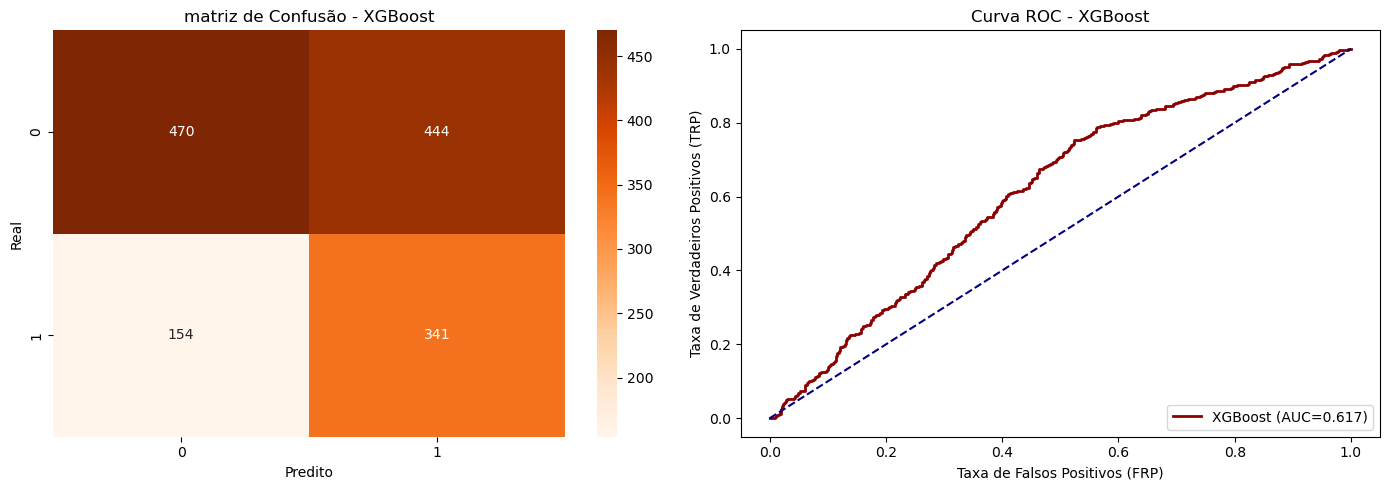

Modelo salvo em: ../models/xgboost_model.joblib


In [15]:
# 1. Carregamento dos dados processados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# 2. Instanciação e Treinamento do modelo
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print('[Treinamento] Ajustando modelo XGBoost Classifier...')

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metrics='logloss'
)

xgb_model.fit(X_train, y_train)

# 3. Predição e Avaliação de Desempenho
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_xgb)
f1 = f1_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec = recall_score(y_test, y_pred_xgb)

print('=== MÉTRICAS DE AVALIAÇÃO (XGBOOST) === ')
print(f'Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'AUC-ROC: {auc:.4f}')
print(f'f1-Score: {f1:.4f}')
print(f'Precisão: {prec:.4f}')
print(f'Recall: {rec:.4f}\n')

print('Relatório de Classificação Detalhado:')
print(classification_report(y_test, y_pred_xgb))

# 4. Matriz de Confusão e Curva ROC
fig, ax=plt.subplots(1, 2, figsize=(14,5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('matriz de Confusão - XGBoost')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
ax[1].plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})', color='darkred', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FRP)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TRP)')
ax[1].set_title('Curva ROC - XGBoost')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 5. salvando o Modelo Treinado
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)
caminho_modelo = os.path.join(pasta_modelos, 'xgboost_model.joblib')
joblib.dump(xgb_model, caminho_modelo)
print(f'Modelo salvo em: {caminho_modelo}')

<hr>

#### 1. Análise Técnica das Métricas Principais

O resultado do XGBoost Classifier reflete diretamente o impacto do parâmetro de calibração de classes <b>(scale_pos_weight)</b>, ajustando o comportamento do algoritmo para focar na detecção da classe minoritária <b>(Churn = 1)</b>.<br>

* <b>Recall / Sensibilidade (68,89%):</b> Este é o ponto forte deste modelo. Com esta configuração, o XGBoost é capaz de identificar 341 dos 495 clientes em risco real de cancelamento no conjunto teste. O uso do peso posicional impediu que o modelo convergisse para a previsão ingênua da classe majoritária.
* <b>Precisão (43,44%):</b> Indica que, de todos os clientes rotulados pelo modelo como 'prestes a cancelar, aproximadamente 43% realmente cancelaram. Os 57% restantes são falsos positivos (clientes leais que o modelo achou que cancelariam).
* <b>F1-Score (0,5328):</b> A média harmônica entre precisão e recall reflete um equilíbrio sólido para a classe positiva, superando significativamente o Random Forest Base (0,4916).
* <b>AUC-ROC (0,6171):</b> A métrica de ordenação de probabilidade ficou em 0,6171, demonstrando uma capacidade razoável de separação geral entre as duas classes em diferentes limiares de decisão.
* <b>Acurácia Geral (57,56%):</b> A queda na acurácia geral ocorre porque o recall da classe 0 (clientes que permanecem) caiu para 51% (466 acertos e 448 falsos alarmes). Em cenários desbalanceados de Churn, a acurácia isolada é uma métrica secundária e frequentemente enganos

<hr>

#### 2. Interpretação sob a òtica do Negócio de Telecomunicações

* <b>Custo de Falsos Negativos vs. Falsos Positivos:</b> O parâmetro <b>scale_pos_weight</b> forçou o modelo a assumir uma postura "defensiva". Para o negócio, errar dizendo que um cliente vai cancelar quando ele não vai (Falso Positivo) custa apenas o valor de um e-mail de retenção ou desconto. Errar dizendo que um cliente vai ficar quando ele realmente cancela (Falso Negativo) custa a perda do LTV (Lifetime Value) do cliente.
* <b>Eficiência do Filtro:</b> Em vez de a equipe de retenção precisar contatar os 1.409 clientes do lote de teste, o modelo afunila a atuação para 785 clientes sinalizados, cobrindo nearly 70% de todo o churn do período.

<hr>

### 3. Síntese do comportamento do Algoritmo

* O XGBoost cumpriu o objetivo de priorizar a classe de interesse (Minimização de Falsos Negativos), entregando uma performance muito competitiva sem requerer uma busca exaustiva de hiperparâmetros. Ele sacrificou a acurácia na classe majoritária para maximizar a captura da classe de risco, mantendo um equilíbrio funcional no $F_1$-Score e na AUC-ROC.